In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import numpy as np
from tqdm import tqdm
import copy
import random
from datasets import load_dataset

/Users/morteza/w/univercity/TrustworthyAI/HW4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(42)
np.random.seed(42)

In [3]:
dataset = load_dataset("flwrlabs/femnist")

dataset = dataset["train"]
print(dataset)
print(dataset[0])

Dataset({
    features: ['image', 'writer_id', 'hsf_id', 'character'],
    num_rows: 814277
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x11B0E2C30>, 'writer_id': 'f0000_14', 'hsf_id': 0, 'character': 0}


In [4]:
df = pd.DataFrame(dataset)

In [5]:
count_df = []
count_df.append({"name": "writer", "count": len(dataset.unique("writer_id"))})
count_df.append({"name": "character", "count": len(dataset.unique("character"))})
count_df.append({"name": "total count", "count": len(dataset)})

pd.DataFrame(count_df)

,name,count
0,writer,3597
1,character,62
2,total count,814277


Bin 59


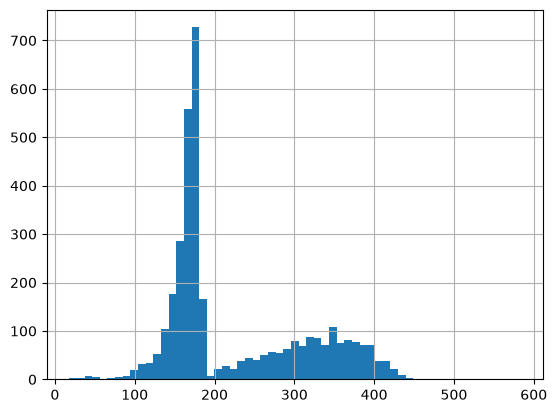

In [55]:
bin_count = len(df["writer_id"].unique())
bin_count = int(bin_count ** 0.5)
print("Bin", bin_count)
df["writer_id"].value_counts().hist(bins=bin_count)
plt.savefig('./report/images/writer_distribution.png')

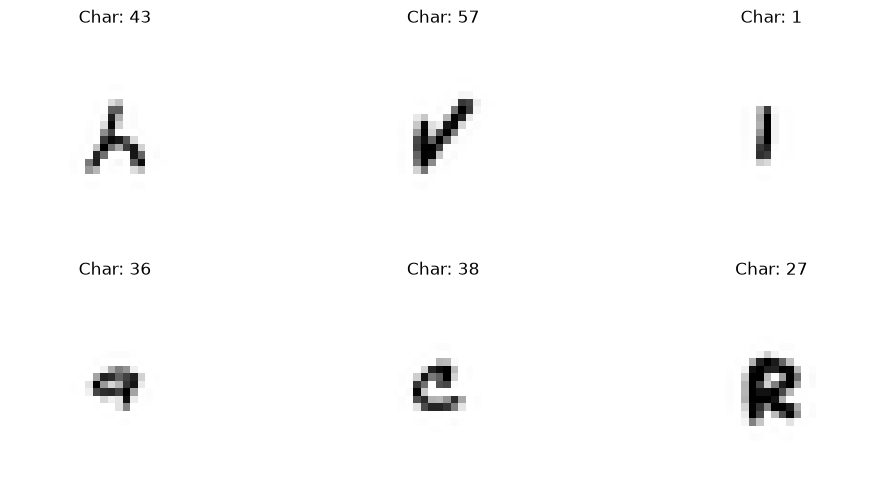

In [54]:
np.random.seed(42)
inds = np.random.choice(len(df), 6, replace=False)
plt.figure(figsize=(12, 6))
for i in range(2):
    for j in range(3):
        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(df.iloc[inds[i * 3 + j]]["image"], cmap="gray")
        plt.title(f"Char: {df.iloc[inds[i * 3 + j]]['character']}")
        plt.axis("off")
plt.savefig('./report/images/sample_images.png')

In [8]:
writers = df["writer_id"].unique()
np.random.seed(42)
np.random.shuffle(writers)
member_writers = writers[: len(writers) - 200]
non_member_writers = writers[len(writers) - 200 :]
assert len(member_writers) + len(non_member_writers) == len(writers)
assert len(set(member_writers).intersection(set(non_member_writers))) == 0
member_df = df[df["writer_id"].isin(member_writers)]
non_member_df = df[df["writer_id"].isin(non_member_writers)]

/var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_30201/1816727735.py:3: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(writers)


In [9]:
count_df = [
    {
        "entity": "writer",
        "is_member": True,
        "count": len(member_writers),
    },
    {
        "entity": "writer",
        "is_member": False,
        "count": len(non_member_writers),
    },
    {
        "entity": "character",
        "is_member": True,
        "count": len(member_df),
    },
    {
        "entity": "character",
        "is_member": False,
        "count": len(non_member_df),
    },
]

count_df = pd.DataFrame(count_df)
count_df

,entity,is_member,count
0,writer,True,3397
1,writer,False,200
2,character,True,769634
3,character,False,44643


In [10]:
np.random.seed(42)
member_writers = member_df["writer_id"].unique()
n_silos = 8
silod_writers = defaultdict(list)
silod_indices = defaultdict(list)
silod_sizes = {}
writer_siloo_count = defaultdict(int)

for idx, row in tqdm(member_df.iterrows(), total = len(member_df)):
    writer_id = row["writer_id"]
    # n_silos_for_writer = np.random.randint(1, n_silos + 1)
    n_silos_for_writer = np.random.choice(
        [1, 2, 3, 4, 5, 6],
        p=[0.45, 0.3, 0.13, 0.07, 0.03, 0.02],
    )
    assigned_silos = np.random.choice(n_silos, n_silos_for_writer, replace=False)
    for silo in assigned_silos:
        silod_indices[silo].append(idx)
        silod_writers[silo].append(writer_id)
    writer_siloo_count[n_silos_for_writer] += 1

for silo in range(n_silos):
    silod_sizes[silo] = len(silod_indices[silo])

print(writer_siloo_count)
print(silod_sizes)


100%|██████████| 769634/769634 [00:16<00:00, 46934.02it/s]

defaultdict(<class 'int'>, {np.int64(1): 346579, np.int64(2): 230960, np.int64(4): 53612, np.int64(3): 100156, np.int64(5): 22942, np.int64(6): 15385})
{0: 191047, 1: 191101, 2: 191310, 3: 191266, 4: 191714, 5: 191462, 6: 191277, 7: 191258}


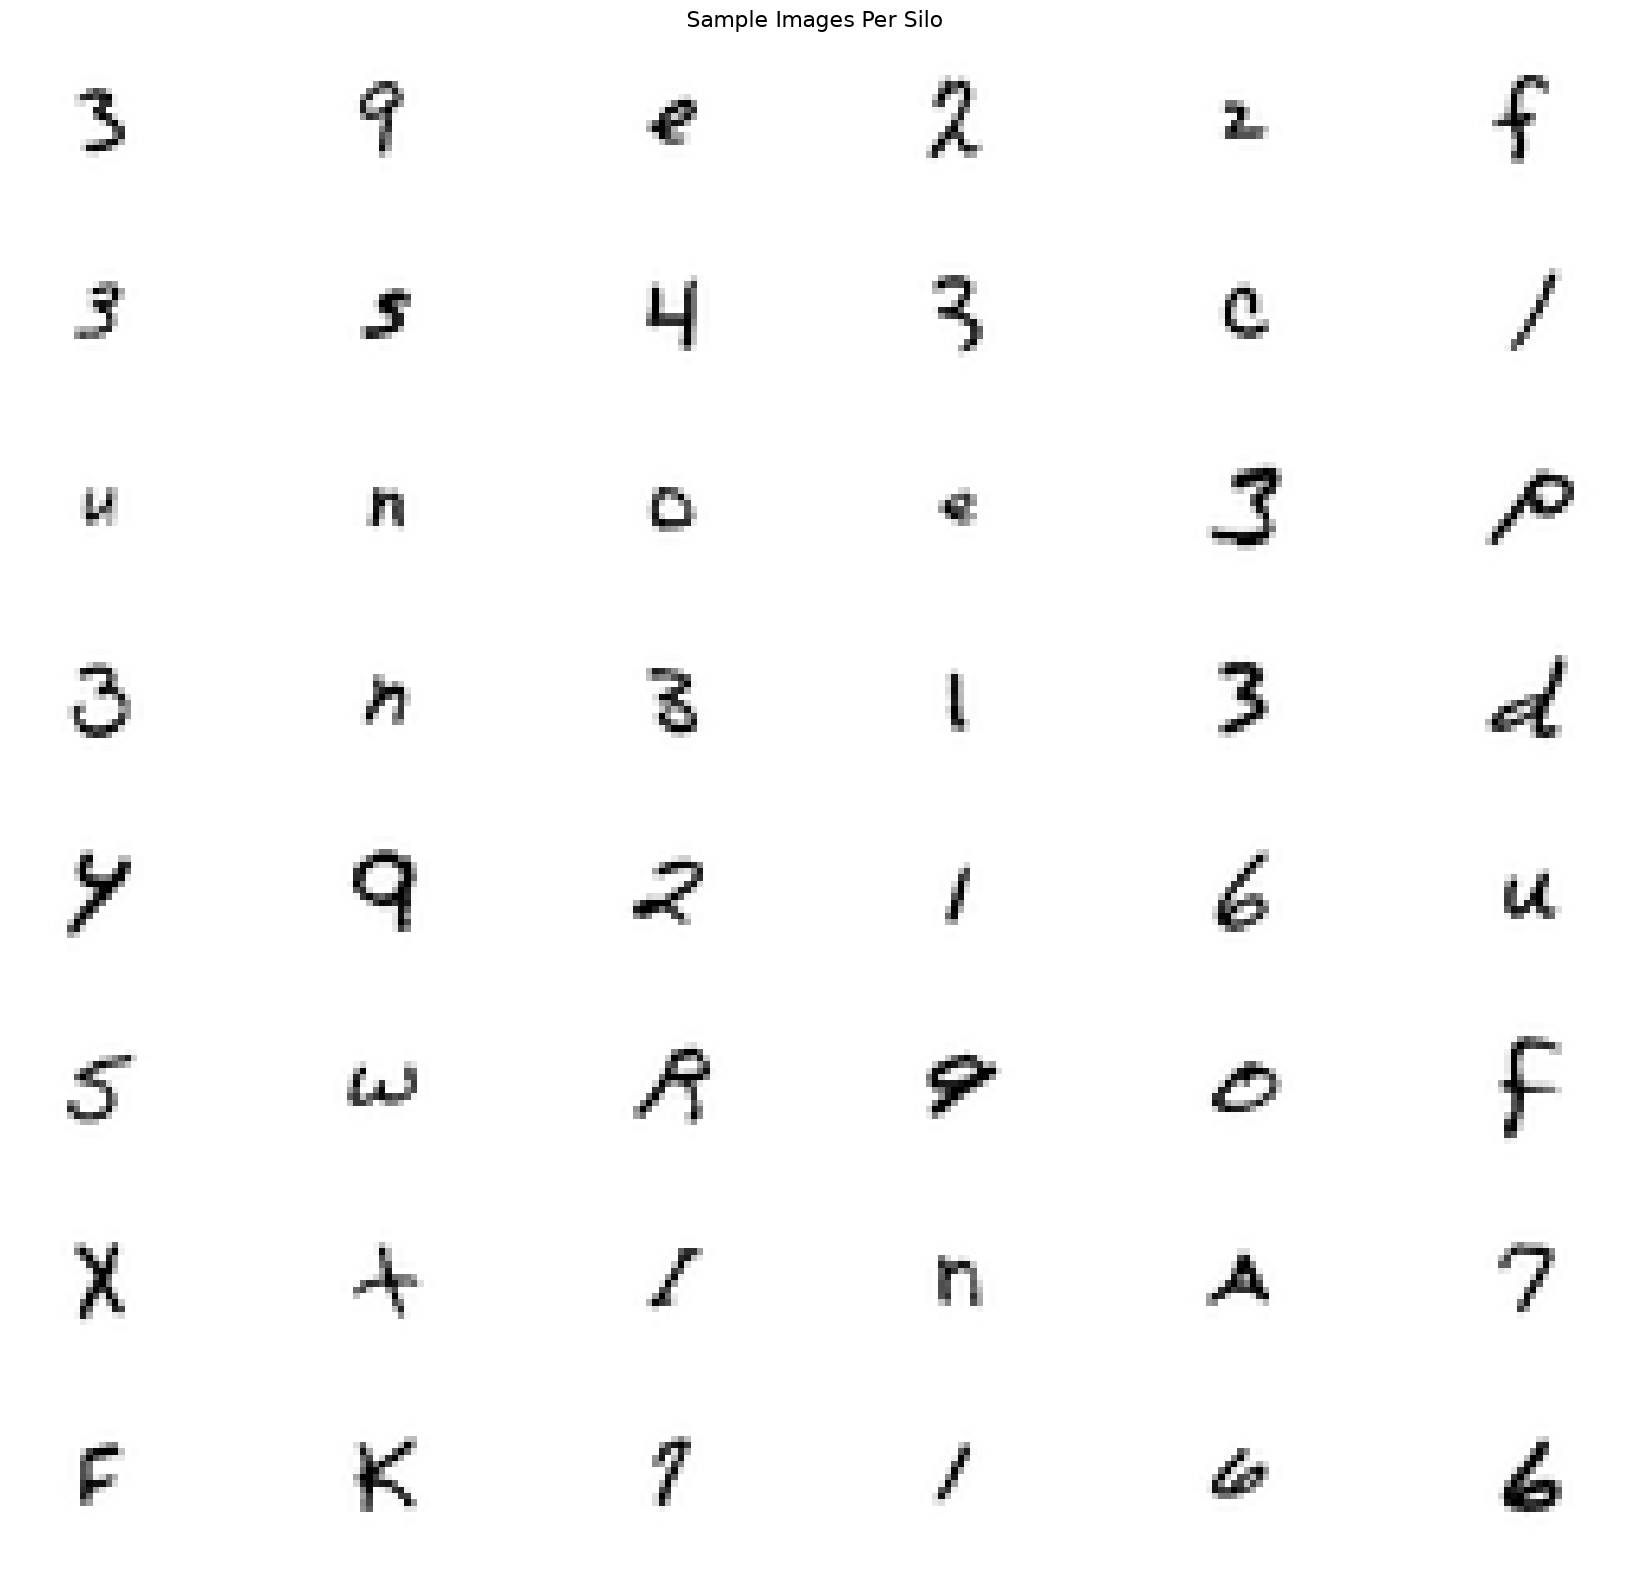

In [50]:
fig, axes = plt.subplots(n_silos, 6, figsize=(18, 2 * n_silos))
fig.suptitle("Sample Images Per Silo", fontsize=16)

for silo in range(n_silos):
    indices = silod_indices[silo]
    np.random.seed(42 + silo)
    sample_indices = np.random.choice(indices, min(6, len(indices)), replace=False)
    for j, idx in enumerate(sample_indices):
        img = member_df.loc[idx]["image"]
        axes[silo, j].imshow(img, cmap="gray")
        axes[silo, j].axis("off")

plt.tight_layout()
plt.savefig('report/images/sample_images_per_silo.png', dpi=150, bbox_inches='tight')
plt.show()


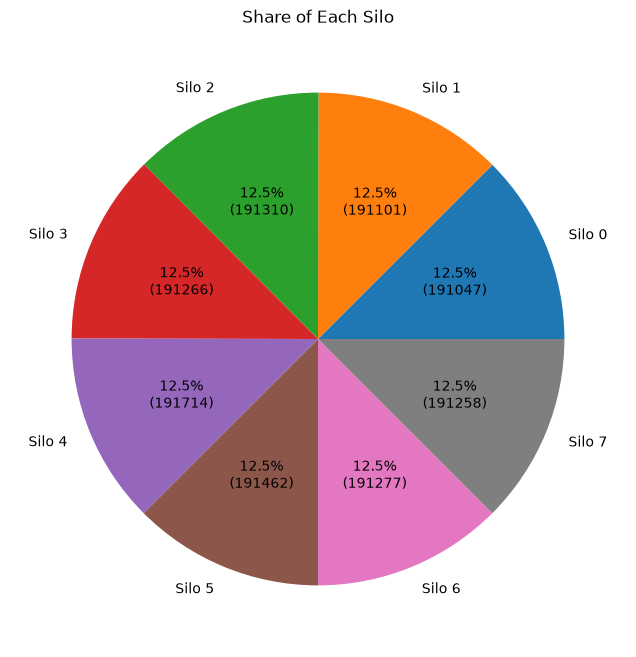

In [47]:
def get_pct_func(total):
    def inner(pct):
            count = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n({count})"
    return inner

plt.figure(figsize=(8, 8))
plt.pie(
    silod_sizes.values(),
    labels=[f"Silo {i}" for i in silod_sizes.keys()],
    autopct=get_pct_func(sum(silod_sizes.values())),
)
plt.title("Share of Each Silo")
plt.savefig('report/images/share_of_each_silo.png', dpi=150, bbox_inches='tight')
plt.show()


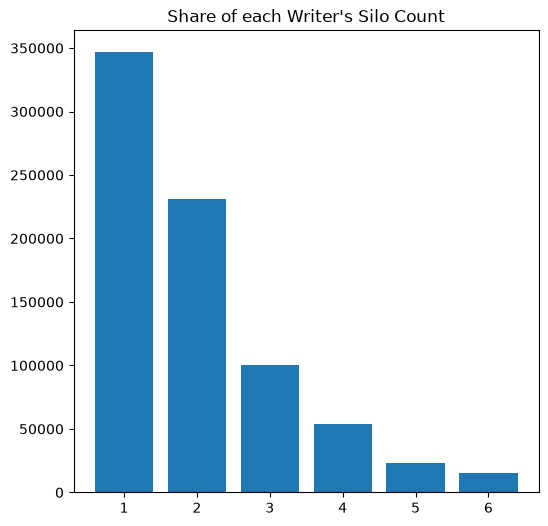

In [48]:
plt.figure(figsize=(6, 6))
bars = list(writer_siloo_count.items())
bars.sort()
plt.bar(
    [i[0] for i in bars],
    [i[1] for i in bars],
)
# plt.pie(
#     writer_siloo_count.values(),
#     labels=[f"Count {i}" for i in writer_siloo_count.keys()],
#     autopct="%1.1f%%",
# )
plt.title("Share of each Writer's Silo Count")
plt.savefig('report/images/writer_silo_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


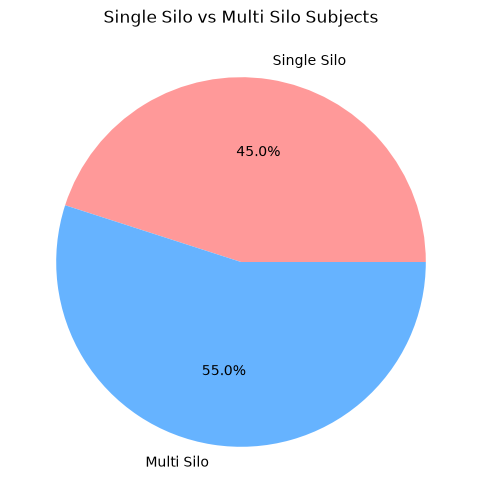

In [49]:
single_silo_writers = writer_siloo_count[1]
multi_silo_writers = sum(j for i, j in writer_siloo_count.items() if i > 1)

plt.figure(figsize=(6, 6))
plt.pie(
    [single_silo_writers, multi_silo_writers],
    labels=["Single Silo", "Multi Silo"],
    autopct="%1.1f%%",
    colors=["#ff9999", "#66b3ff"],
)
plt.title("Single Silo vs Multi Silo Subjects")
plt.savefig('report/images/single_vs_multi_silo.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

member_df_aligned = member_df.reset_index(drop=True)
non_member_df_aligned = non_member_df.reset_index(drop=True)

X = np.array([np.array(img) for img in member_df_aligned["image"]], dtype=np.float32) / 255.0
X = X[:, np.newaxis, :, :]
y = member_df_aligned["character"].astype(int).values

X_test = np.array([np.array(img) for img in non_member_df_aligned["image"]], dtype=np.float32) / 255.0
X_test = X_test[:, np.newaxis, :, :]
y_test = non_member_df_aligned["character"].astype(int).values

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Train shape: {X_tensor.shape}, Test shape: {X_test_tensor.shape}")
print(f"Number of classes: {len(torch.unique(y_tensor))}")

index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(member_df.index)}

silo_data = {}
silo_loaders = {}
for silo in range(n_silos):
    positional_indices = np.array([index_map[idx] for idx in silod_indices[silo]])
    X_silo = X_tensor[positional_indices]
    y_silo = y_tensor[positional_indices]
    silo_data[silo] = {
        "X": X_silo,
        "y": y_silo,
        "writers": list(set(member_df_aligned.iloc[positional_indices]["writer_id"])),
    }
    dataset = TensorDataset(X_silo, y_silo)
    silo_loaders[silo] = DataLoader(dataset, batch_size=128, shuffle=True)
    print(f"Silo {silo}: {len(positional_indices)} samples, {len(silo_data[silo]['writers'])} writers")


Train shape: torch.Size([769634, 1, 28, 28]), Test shape: torch.Size([44643, 1, 28, 28])
Number of classes: 62
Silo 0: 191047 samples, 3397 writers
Silo 1: 191101 samples, 3397 writers
Silo 2: 191310 samples, 3397 writers
Silo 3: 191266 samples, 3397 writers
Silo 4: 191714 samples, 3397 writers
Silo 5: 191462 samples, 3397 writers
Silo 6: 191277 samples, 3397 writers
Silo 7: 191258 samples, 3397 writers


In [56]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),

    nn.Linear(32, 128),
    nn.ReLU(),

    nn.Linear(128, 62),
)

In [59]:
np.random.seed(42)
torch.manual_seed(42)
n_rounds = 5
local_epochs = 1
lr = 0.05
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Using device: {device}")

global_model = model.to(device)
criterion = nn.CrossEntropyLoss()
history = {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []}

def evaluate(model, X, y, batch_size=256):
    model.eval()

    correct = 0
    total = 0
    loss = 0

    with torch.no_grad():
        for i in tqdm(range(0, len(X), batch_size), desc="Evaluating"):
            X_batch = X[i:i+batch_size].to(device)
            y_batch = y[i:i+batch_size].to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
            loss += criterion(outputs, y_batch).item() * len(y_batch)

    return correct / total, loss / total

def train_model(model, X, y):
    X, y= X.to(device), y.to(device)
    optimizer.zero_grad()
    outputs = local_model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
 
for round_idx in range(n_rounds):
    local_state_dicts = []
    
    for silo in range(n_silos):
        local_model = copy.deepcopy(global_model).to(device)
        optimizer = optim.SGD(local_model.parameters(), lr=lr, momentum=0.9)
        
        local_model.train()
        for _ in range(local_epochs):
            for X_batch, y_batch in tqdm(silo_loaders[silo], desc=f"Round {round_idx+1}/{n_rounds} - Silo {silo+1}/{n_silos}"):
                train_model(local_model, X_batch, y_batch)

        
        local_state_dicts.append(local_model.state_dict())
    
    averaged_state_dict = {}
    for key in local_state_dicts[0]:
        averaged_state_dict[key] = torch.mean(
            torch.stack([sd[key] for sd in local_state_dicts]), dim=0
        )
    
    global_model.load_state_dict(averaged_state_dict)
    
    global_model.eval()
    train_acc, train_loss = evaluate(global_model, X_tensor, y_tensor)
    test_acc, test_loss = evaluate(global_model, X_test_tensor, y_test_tensor)

    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    
    print(f"Round {round_idx+1}/{n_rounds} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


Using device: mps


Evaluating: 100%|██████████| 175/175 [00:00<00:00, 322.73it/s]


Round 1/5 | Train Acc: 0.0905 | Test Acc: 0.0930


Evaluating: 100%|██████████| 175/175 [00:00<00:00, 366.97it/s]


Round 2/5 | Train Acc: 0.1954 | Test Acc: 0.1995


...

Round 3/5 | Train Acc: 0.7503 | Test Acc: 0.7551


Evaluating: 100%|██████████| 175/175 [00:00<00:00, 358.52it/s]


Round 4/5 | Train Acc: 0.7830 | Test Acc: 0.7879


Evaluating: 100%|██████████| 175/175 [00:00<00:00, 236.13it/s]

Round 5/5 | Train Acc: 0.8004 | Test Acc: 0.8042


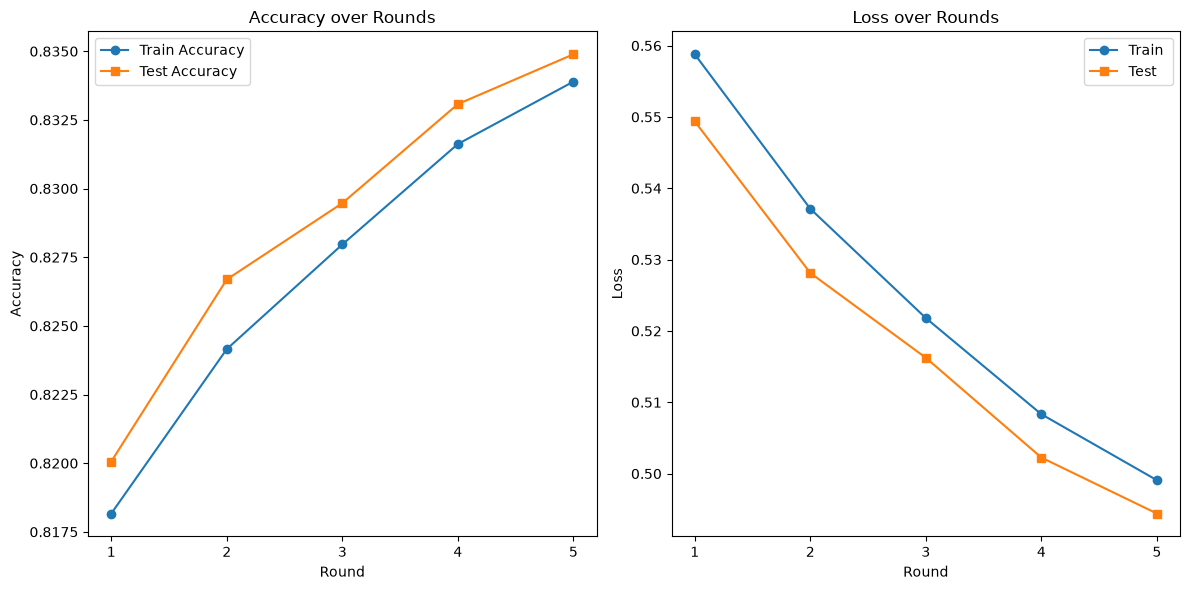

In [46]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_rounds+1), history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(range(1, n_rounds+1), history["test_acc"], marker="s", label="Test Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Accuracy over Rounds")
plt.legend()
plt.xticks(range(1, n_rounds+1))

plt.subplot(1, 2, 2)
plt.plot(range(1, n_rounds+1), history["train_loss"], marker="o", label="Train ")
plt.plot(range(1, n_rounds+1), history["test_loss"], marker="s", label="Test ")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.title("Loss over Rounds")
plt.legend()
plt.xticks(range(1, n_rounds+1))

plt.tight_layout()
plt.savefig('report/images/federated_learning_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
